# Mi-Projet: Analyse des données et pre-processing

Eduardo Cobos Fernandez

Fairness en IA 

Dans ce notebook on va analyser les données que l'on nous a donné et appliquer une méthode de pré-processing pour réduire les bias identifiés.

# Introduction (explication du cas d’usage et de l’objectif)

Les modèles de prédiction sont de plus en plus utilisés dans le domaine médical, notamment pour l’aide au diagnostic à partir de données patients et d’imagerie médicale. Toutefois, ces modèles peuvent hériter de biais présents dans les données utilisées pour leur apprentissage, ce qui rend nécessaire une analyse préalable de ces données.

Ce mi-projet s’appuie sur le dataset Chest X-ray NIH14 (https://www.kaggle.com/datasets/nih-chest-xrays/data), qui contient des radiographies thoraciques ainsi que des métadonnées associées aux patients, telles que l’âge, le genre et les pathologies diagnostiquées. Pour cette étape intermédiaire du projet, l’analyse se limite aux métadonnées, les images n’étant pas considérées. Un sous-ensemble de 15.000 radiographies est utilisé.

L’objectif de ce travail est d’analyser les métadonnées afin d’identifier d’éventuels biais liés à des attributs sensibles, puis d’appliquer une méthode de pré-processing pour réduire ces biais et construire un dataset transformé. Ce travail constitue une étape préparatoire au projet final, dans lequel l’impact du pré-processing sur un modèle basé sur les images sera étudié.


# Chargement et préparation des données

Les métadonnées du dataset Chest X-ray NIH14 sont chargées à partir du fichier fourni pour le mi-projet. Ce fichier contient les informations associées à un sous-ensemble de 15 000 patients.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

In [5]:
# On commence par charger les donnees depuis le csv
df = pd.read_csv("Cobos_Fernandez_Eduardo/metadata.csv")

# On peut regarder les premieres lignes du dataset 
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1


On peut chercher à savoir des informations imprtantes du dataset

In [6]:
features = df.columns.tolist()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5593 entries, 0 to 5592
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5593 non-null   object 
 1   Finding Labels               5593 non-null   object 
 2   Follow-up #                  5593 non-null   int64  
 3   Patient ID                   5593 non-null   int64  
 4   Patient Age                  5593 non-null   int64  
 5   Patient Gender               5593 non-null   object 
 6   View Position                5593 non-null   object 
 7   OriginalImage[Width          5593 non-null   int64  
 8   Height]                      5593 non-null   int64  
 9   OriginalImagePixelSpacing[x  5593 non-null   float64
 10  y]                           5593 non-null   float64
 11  Unnamed: 11                  0 non-null      float64
 12  train_valid                  5593 non-null   object 
 13  label             

On observe que le dataset contient 54737 observations de patients et 11 variables.
Ces variables sont composées d'informations démographiques (age, genre), d'informations techniques (position de vue, taille de l'image originelle, le spacing des pixels) ainsi que le nombre de visites effectués préalablement et la maladie les maladies diagnostiqués si il en a. Cette dernière infomartion sera notre label car l'objectif est de prédire si le patient est malade ou pas et identifier la maladie s'il l'est.

Il sera intéressant de vérifier si un data cleaning est a effectuer sur les données. Pour celà on va vérifier si notre dataset contient des lignes avec des valeurs manquantes et si c'est le cas décider comment les traiter (supprimer la ligne, donner une valeur à la donnée manquante arbitraire, etc). De plus, faudra aussi regarder si il n'y a pas de valeurs abérantes dans le dataset, des personnes âgées de 200 ans par exemple, et traiter ces valeurs (supprimer la ligne entière, la valeur uniquement, remplacer la valeur, etc)

In [7]:
# On regarde pour chaque variable si il y a des valeurs manquantes, meme si df.info() nous a deja donnee la reponse
df.isnull().sum()

Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    5593
train_valid                       0
label                             0
WEIGHTS                           0
dtype: int64

Donc pas de valeurs nulles dans notre dataset, pas besoin de traiter nos données pour ceci

Les types des valeurs sont bien placés comme on observe avec df.info(), donc rien à modifier

On remarque que les informations OriginalImage[Width, Height] et OriginalImagePixelSpacing[x y] données par les colonnes 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]' n'apportent aucune information intéressante. On peut donc procéder à le supprimer.

In [8]:
df = df.drop(columns=['OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]'])

Afin de faciliter l'analyse et l'entrainement du modèle (le but final est de dire si le patient est malade ou pas) on va créer une colonne qui dit si le patient est malade 

In [9]:
#Creation d'une nouvelle colonne "est malade"
df["Has_Disease"] = df["Finding Labels"] != "No Finding"

In [10]:
#nouvelle table
df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,Unnamed: 11,train_valid,label,WEIGHTS,Has_Disease
0,00000011_000.png,Effusion,0,11,75,M,PA,NaN,train,malade,1,True
1,00000011_001.png,No Finding,1,11,75,M,PA,NaN,train,sain,1,False
2,00000011_002.png,No Finding,2,11,75,M,PA,NaN,train,sain,1,False
3,00000011_003.png,No Finding,3,11,75,M,PA,NaN,train,sain,1,False
4,00000011_004.png,No Finding,4,11,75,M,PA,NaN,train,sain,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,Consolidation,1,30772,26,F,AP,NaN,train,malade,1,True
5589,00030772_002.png,Consolidation,2,30772,26,F,AP,NaN,train,malade,1,True
5590,00030774_000.png,Consolidation,0,30774,44,F,PA,NaN,valid,malade,1,True
5591,00030784_000.png,No Finding,0,30784,25,F,PA,NaN,train,sain,1,False


On cherche à détecter des données abhérrantes. On va donc anlayser les colonnes une par une

In [11]:
# follow ups
print(df[features[2]].min())
print(df[features[2]].max())

0
172


Il n'y a pas de follow ups négatives et même si 157 est un grand nombre c'est enviseageable

In [12]:
#patient id

len(df[features[3]].unique())

#donc plusieures images d'une meme personne 

1500

In [13]:
# patient age

print(df[features[4]].min())
print(df[features[4]].max())

#faut travailler sur les ages > 100

(df[features[4]] > 100).sum()

#faire une box 

1
148


np.int64(1)

Il n'y pas d'âges négatifs mais il y a des âges beaucoup trop élevées, c'est des valeurs abhérantes qu'il faut traiter. On observe qu'il n'y a pas beaucoup de lignes avec des âges abhérrants donc on peut les supprimer, ça ne changera pas trop notre étude. On va juste garder les âges plus petits ou égaux à 100. On aurait pu regarder en fonction du ID Patient si c'était juste une erreur de frappe lors de l'enregistrement des données (très probable), mais étant le nb de valeurs abhérrantes aussi petit, on peu juste les suprimer. 

In [14]:
df = df[df["Patient Age"] <= 100]

In [15]:
# patient gender 

print(df[features[5]].unique())

['M' 'F']


Les valeurs de genre sont notés M pour les hommes et F pour les femmes. On voit que les seules valeures possibles sont que ces deux là. Donc pas de valeurs abhérrantes dans cette colonne

In [16]:
#view position
print(df[features[6]].unique())


['PA' 'AP']


Les valeurs de genre sont notés PA et AP. On voit que les seules valeures possibles sont que ces deux là. Donc pas de valeurs abhérrantes dans cette colonne

On a fini le traitement des valeurs abhérrantes. Il a juste fallu intervenir pour la colonne des âges, le reste de colonne ne comportent pas de données abhérrantes

Pour l'analyse descriptive des données on va procéder à faire un multi one-hot encoding sur la colonne finding labels en créant une colonne par maladie.
De plus, afin de simplifier la lecture des données âge et pouvoir les utiliser dans le préprocessing on va la transformer en une donnée catégorielle en créant des tranches d'âges:


In [17]:
# on commence par créer les tranches d'ages
df["Age_Group"] = pd.cut(
    df["Patient Age"],
    bins=[0, 20, 40, 60, 80, 120],
    labels=["0-20", "20-40", "40-60", "60-80", "80+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin 

/var/folders/2s/g233_y4543g3nv84_mqys8bc0000gp/T/ipykernel_13558/947966111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age_Group"] = pd.cut(


In [18]:
# on fait le one_hot sur les phatologies
dummies = df["Finding Labels"].str.get_dummies(sep="|")

df_one_hot = pd.concat([df, dummies], axis=1)
df_one_hot = df_one_hot.drop(columns=["Finding Labels"])


In [19]:
df_one_hot

,Image Index,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,Unnamed: 11,train_valid,label,WEIGHTS,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000011_000.png,0,11,75,M,PA,NaN,train,malade,1,...,0,0,0,0,0,0,0,0,0,0
1,00000011_001.png,1,11,75,M,PA,NaN,train,sain,1,...,0,0,0,0,0,1,0,0,0,0
2,00000011_002.png,2,11,75,M,PA,NaN,train,sain,1,...,0,0,0,0,0,1,0,0,0,0
3,00000011_003.png,3,11,75,M,PA,NaN,train,sain,1,...,0,0,0,0,0,1,0,0,0,0
4,00000011_004.png,4,11,75,M,PA,NaN,train,sain,1,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,1,30772,26,F,AP,NaN,train,malade,1,...,0,0,0,0,0,0,0,0,0,0
5589,00030772_002.png,2,30772,26,F,AP,NaN,train,malade,1,...,0,0,0,0,0,0,0,0,0,0
5590,00030774_000.png,0,30774,44,F,PA,NaN,valid,malade,1,...,0,0,0,0,0,0,0,0,0,0
5591,00030784_000.png,0,30784,25,F,PA,NaN,train,sain,1,...,0,0,0,0,0,1,0,0,0,0


In [20]:
df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,Unnamed: 11,train_valid,label,WEIGHTS,Has_Disease,Age_Group
0,00000011_000.png,Effusion,0,11,75,M,PA,NaN,train,malade,1,True,60-80
1,00000011_001.png,No Finding,1,11,75,M,PA,NaN,train,sain,1,False,60-80
2,00000011_002.png,No Finding,2,11,75,M,PA,NaN,train,sain,1,False,60-80
3,00000011_003.png,No Finding,3,11,75,M,PA,NaN,train,sain,1,False,60-80
4,00000011_004.png,No Finding,4,11,75,M,PA,NaN,train,sain,1,False,60-80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,Consolidation,1,30772,26,F,AP,NaN,train,malade,1,True,20-40
5589,00030772_002.png,Consolidation,2,30772,26,F,AP,NaN,train,malade,1,True,20-40
5590,00030774_000.png,Consolidation,0,30774,44,F,PA,NaN,valid,malade,1,True,40-60
5591,00030784_000.png,No Finding,0,30784,25,F,PA,NaN,train,sain,1,False,20-40


Conclusion et explication des données finales 

# Analyse descriptive et observation des bias

On va commencer à faire l'analyse univarié des valeurs, c'est à dire prendfre les colonnes une par une et les analyser de façon unique. Puis on fera l'analyse bivarié où on va analyser des colonnes mises ensemble (Gêne et maldie ansi que gêne et pathologie puis âge et maladie ainsi que âge et pathologies)


# Analyse Univariée

On va regarder les données une par une et les anlyser. On va cependant aussi regarder en fonction du Patient Id afin d'analyser les 50000 images mais aussi les 15000 patients

Dans le dataset on a 1500 patients différents
Le nombre d'images moyennes par patient est 3.728


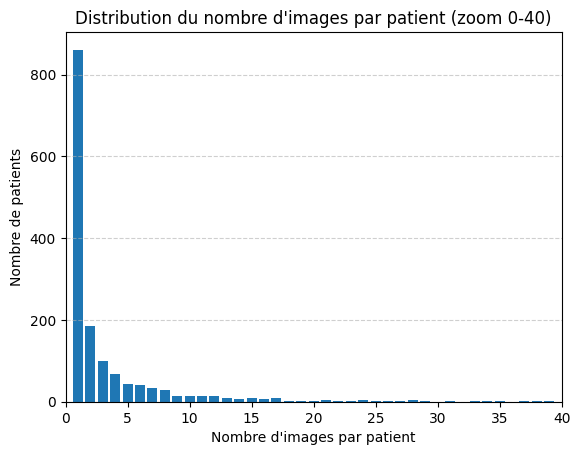

In [21]:
#patient Id

print(f"Dans le dataset on a {df["Patient ID"].nunique()} patients différents")

print(f"Le nombre d'images moyennes par patient est {df["Patient ID"].value_counts().mean()}")

plt.bar(df["Patient ID"].value_counts().value_counts().index, df["Patient ID"].value_counts().value_counts().values)
plt.xlim(0, 40)  # Zoom sur la zone dense
plt.xlabel("Nombre d'images par patient")
plt.ylabel("Nombre de patients")
plt.title("Distribution du nombre d'images par patient (zoom 0-40)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [22]:
# follow ups 

#On regarde pour chaque patient combien de follow ups il a fait
max_followups_par_patient = df.groupby("Patient ID")["Follow-up #"].max()

print(f"Dans le dataset on a {(df["Follow-up #"]>0).sum()} données avec des follows up supérieurs à 0, ce qui correspond à {(df["Follow-up #"]>0).mean()*100 :.2f}% des données")
print(f"On a {(df["Follow-up #"]>5).sum()} données avec des follows up supérieurs à 5, {(df["Follow-up #"]>5).mean()*100 :.2f}% des données")
print(f"{(df["Follow-up #"]>15).sum()} avec des follows up supérieurs à 15, {(df["Follow-up #"]>15).mean()*100 :.2f}% des données")
print(f"Et {(df["Follow-up #"]>40).sum()} avec des follows up supérieurs à 40, {(df["Follow-up #"]>40).mean()*100 :.2f}% des données\n")

print(f"Dans le dataset on a {(max_followups_par_patient > 0).sum()} patients avec des follows up supérieurs à 0, soit le {(max_followups_par_patient>0).mean()*100 :.2f}%")
print(f"Et on a {(max_followups_par_patient > 40).sum()} patients avec des follows up supérieurs à 40, soit le {(max_followups_par_patient>40).mean()*100 :.2f}%")

Dans le dataset on a 4092 données avec des follows up supérieurs à 0, ce qui correspond à 73.18% des données
On a 2113 données avec des follows up supérieurs à 5, 37.79% des données
972 avec des follows up supérieurs à 15, 17.38% des données
Et 329 avec des follows up supérieurs à 40, 5.88% des données

Dans le dataset on a 639 patients avec des follows up supérieurs à 0, soit le 42.60%
Et on a 11 patients avec des follows up supérieurs à 40, soit le 0.73%


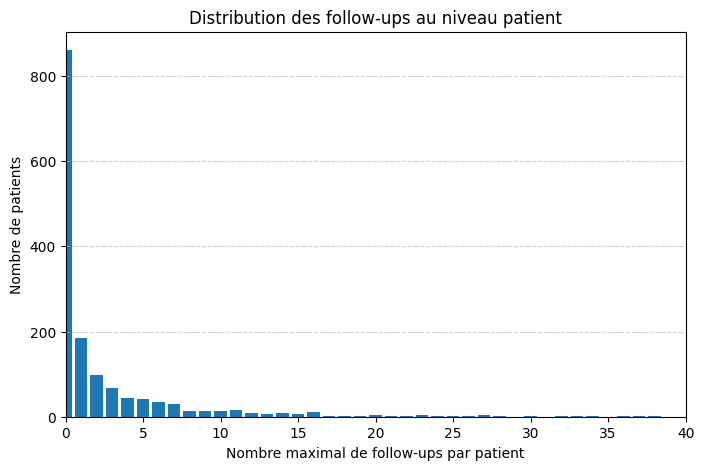

In [23]:
plt.figure(figsize=(8,5))
plt.bar((max_followups_par_patient.value_counts().sort_index()).index, (max_followups_par_patient.value_counts().sort_index()).values)

plt.xlim(0, 40)
plt.xlabel("Nombre maximal de follow-ups par patient")
plt.ylabel("Nombre de patients")
plt.title("Distribution des follow-ups au niveau patient")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

Dans le dataset le 59.78% des données sont prélévées d'hommes et le 40.22% de femmes
Dans le dataset le 57.33% des données sont prélévées d'hommes et le 42.67% de femmes


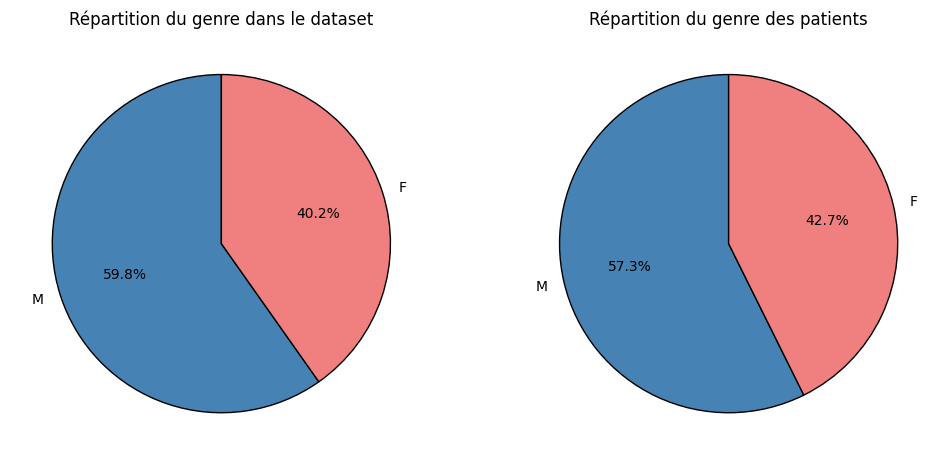

In [24]:
# patient gender

#On regarde la réprtition des images par genre
print(f"Dans le dataset le {df["Patient Gender"].value_counts(normalize=True)["M"] * 100 :0.2f}% des données sont prélévées d'hommes et le {df["Patient Gender"].value_counts(normalize=True)["F"] * 100 :0.2f}% de femmes")

#on regarde en fonction du patient Id, comme ça on sait si c'est la même personne aec différentes radiograohies qui fait changer les valeures
print(f"Dans le dataset le {df.groupby("Patient ID")["Patient Gender"].first().value_counts(normalize=True)["M"] *100 :0.2f}% des données sont prélévées d'hommes et le {df.groupby("Patient ID")["Patient Gender"].first().value_counts(normalize=True)["F"] *100 :0.2f}% de femmes")

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].pie(
    df["Patient Gender"].value_counts(),
    labels=df["Patient Gender"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[0].set_title("Répartition du genre dans le dataset")

axes[1].pie(
    df.groupby("Patient ID")["Patient Gender"].first().value_counts(),
    labels=df.groupby("Patient ID")["Patient Gender"].first().value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[1].set_title("Répartition du genre des patients")

plt.show()

count    5592.000000
mean       48.306688
std        15.914147
min         1.000000
25%        38.000000
50%        51.000000
75%        59.000000
max        93.000000
Name: Patient Age, dtype: float64

count    1500.000000
mean       45.939333
std        16.655467
min         1.000000
25%        34.000000
50%        48.000000
75%        58.000000
max        93.000000
Name: Patient Age, dtype: float64


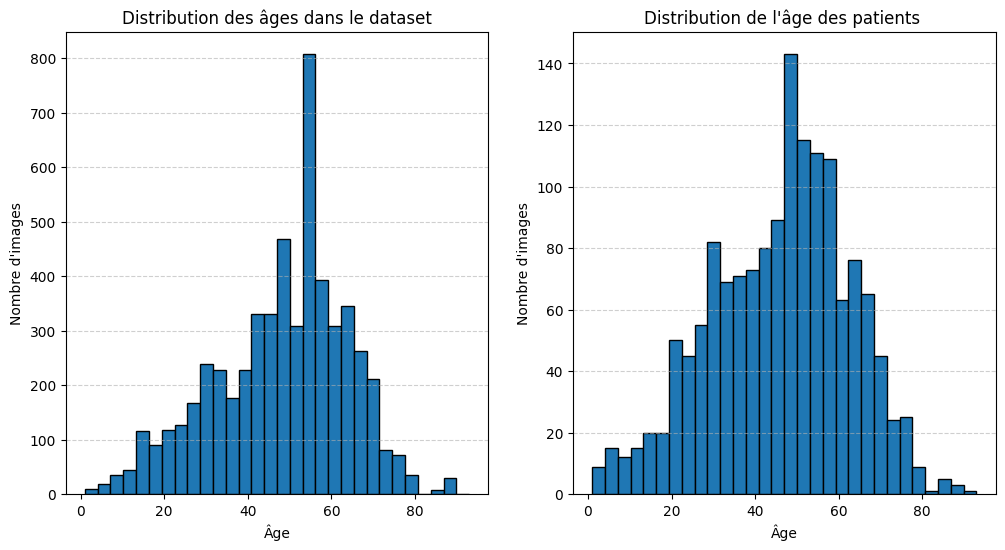

In [25]:
# age et age groups 

print(df["Patient Age"].describe())
print()
print(df.groupby("Patient ID")["Patient Age"].first().describe())


fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].hist(df["Patient Age"], bins=30, edgecolor="black")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des âges dans le dataset")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

axes[1].hist(df.groupby("Patient ID")["Patient Age"].first(), bins=30, edgecolor="black")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Nombre d'images")
axes[1].set_title("Distribution de l'âge des patients ")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

On observe notamment que la moyenne est supérieure à la médianne donc les données sont asymétriques

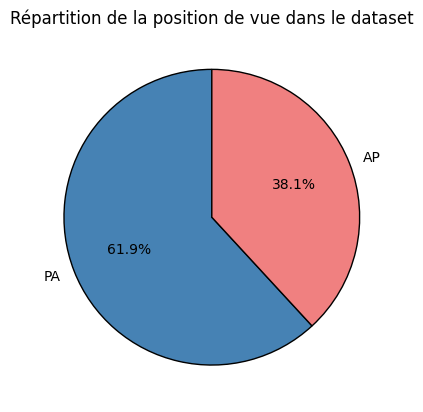

In [26]:
# view position
plt.pie(
    df["View Position"].value_counts(),
    labels=df["View Position"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
plt.title("Répartition de la position de vue dans le dataset")

plt.show()


In [27]:
#
print(f"On remarque que {(df.groupby("Patient ID")["View Position"].nunique() -1).mean() *100 :0.2f}% des patients ont effectué les deux tests")

On remarque que 23.33% des patients ont effectué les deux tests


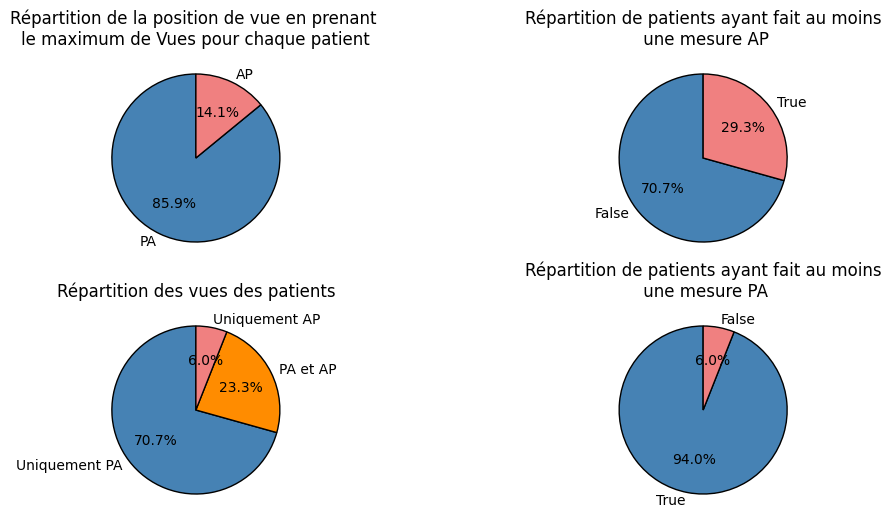

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12,6))

axes[0][0].pie(
    df.groupby("Patient ID")["View Position"] \
  .agg(lambda x: x.value_counts().idxmax()).value_counts(),
    labels=df.groupby("Patient ID")["View Position"] \
  .agg(lambda x: x.value_counts().idxmax()).value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[0][0].set_title("Répartition de la position de vue en prenant \nle maximum de Vues pour chaque patient")

axes[0][1].pie(
    df.groupby("Patient ID")["View Position"] \
           .apply(lambda x: "AP" in x.values).value_counts(),
    labels=df.groupby("Patient ID")["View Position"] \
           .apply(lambda x: "AP" in x.values).value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[0][1].set_title("Répartition de patients ayant fait au moins\n une mesure AP")


axes[1][1].pie(
    df.groupby("Patient ID")["View Position"] \
           .apply(lambda x: "PA" in x.values).value_counts(),
    labels=df.groupby("Patient ID")["View Position"] \
           .apply(lambda x: "PA" in x.values).value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[1][1].set_title("Répartition de patients ayant fait au moins\n une mesure PA")

view_per_patient = df.groupby("Patient ID")["View Position"].agg(lambda x: set(x))
def classify_views(views):
    if views == {"PA"}:
        return "Uniquement PA"
    elif views == {"AP"}:
        return "Uniquement AP"
    else:
        return "PA et AP"
aa = view_per_patient.apply(classify_views)
a = aa.value_counts()
axes[1][0].pie(
    a,
    labels= a.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "darkorange", "lightcoral"],
    wedgeprops={"edgecolor": "black"}
)
axes[1][0].set_title("Répartition des vues des patients")

plt.show()

On remarque que beaucoup de données sont avec une vue AP mais car les personnes qui font une vue AP on récurence à faire plus de follow ups donc a additioner plus de radiographies AP au dataset 

In [29]:
# maladies et pathologies
print(f"On remarque que {df["Has_Disease"].value_counts()[True]} données du dataset présentent une maladie, soit le {df["Has_Disease"].value_counts(normalize=True)[True]*100 :0.2f}%")
print(f"Si on regarde par patient et non par images on a {df.groupby("Patient ID")["Has_Disease"].max().value_counts(normalize=True)[True] *100 :0.2f}% des patiens qui ont été malades aux moins une fois")
print(f"Et que {df.groupby("Patient ID")["Has_Disease"].min().value_counts(normalize=True)[True] *100 :0.2f}% des patiens ont été malades à tous les radiographies")

On remarque que 2653 données du dataset présentent une maladie, soit le 47.44%
Si on regarde par patient et non par images on a 47.47% des patiens qui ont été malades aux moins une fois
Et que 20.20% des patiens ont été malades à tous les radiographies


Contrairement aux variables âge et genre, le fait que le patient soit malade ou sain peut évoluer au cours du temps. Un même patient peut apparaître sain lors d'une radiographie et malade lors de la suivante.  
Ainsi, l’analyse au niveau image est privilégiée. Faire l'analyse au niveau patient ferait perdre l'information liée à l'évolution du patient au cours du temps. Nou analysons donc la variable Has_Disease ainsi que les differentes patologies uniquement par rapport aux images.

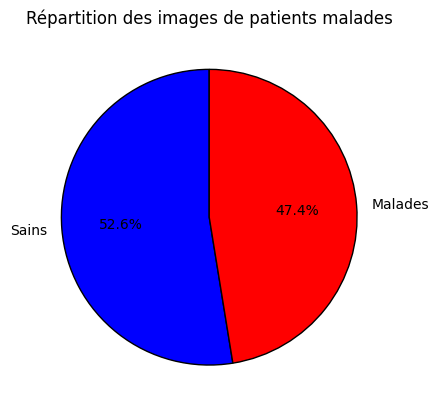

In [30]:
plt.pie(
    df["Has_Disease"].value_counts(),
    labels= ["Sains","Malades"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["blue", "red"],
    wedgeprops={"edgecolor": "black"}
)
plt.title("Répartition des images de patients malades")

plt.show()

Le dataset présente un petit déséquilibre entre patients malades et sains. Mais il est très petit, 53.9% d'images de patients sains pour 46.1% de malades. On peut passer à l'analyse plus fine des patients malades en analysant les patologies une par une.

In [31]:
dummies.sum().sort_values(ascending=False)

No Finding            2939
Infiltration          1014
Effusion               670
Atelectasis            530
Nodule                 356
Consolidation          296
Mass                   283
Pneumothorax           280
Pleural_Thickening     190
Cardiomegaly           158
Edema                  129
Emphysema              114
Fibrosis                98
Pneumonia               63
Hernia                   8
dtype: int64

In [32]:
print("Proportion de chaque catégorie de maladie et de non malades dans le dataset total:")
print((dummies.sum().sort_values(ascending=False) / len(df)) * 100)

df_malades = df_one_hot[df_one_hot["Has_Disease"] == True]
maladies = dummies.columns.drop("No Finding")
repart_maladies = (df_malades[maladies].mean()*100).sort_values(ascending=False)

print("\nProportion de chaque catégorie de maladie dans le dataset des malades:")
print(repart_maladies)

#total de tout > 100 okay car on peut avoir plusieures pathologies en même temps pour une même image

Proportion de chaque catégorie de maladie et de non malades dans le dataset total:
No Finding            52.557225
Infiltration          18.133047
Effusion              11.981402
Atelectasis            9.477825
Nodule                 6.366237
Consolidation          5.293276
Mass                   5.060801
Pneumothorax           5.007153
Pleural_Thickening     3.397711
Cardiomegaly           2.825465
Edema                  2.306867
Emphysema              2.038627
Fibrosis               1.752504
Pneumonia              1.126609
Hernia                 0.143062
dtype: float64

Proportion de chaque catégorie de maladie dans le dataset des malades:
Infiltration          38.220882
Effusion              25.254429
Atelectasis           19.977384
Nodule                13.418771
Consolidation         11.157181
Mass                  10.667169
Pneumothorax          10.554090
Pleural_Thickening     7.161704
Cardiomegaly           5.955522
Edema                  4.862420
Emphysema              4.29702

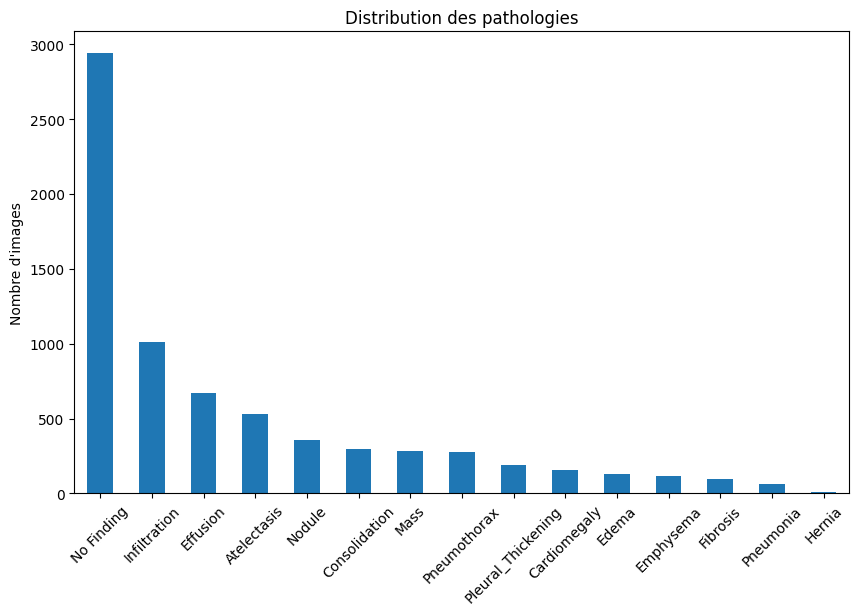

In [33]:
plt.figure(figsize=(10,6))
dummies.sum().sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Nombre d'images")
plt.title("Distribution des pathologies")
plt.xticks(rotation=45)
plt.show()

In [34]:
# On va faire un diagramme circulaire présentant les proportion d'images avec une certaine maladie dans toutes les images avec au moins une maladie
def plot_disease(maladie):
    plt.figure(figsize=(6,6))
    plt.pie(
        [repart_maladies[maladie], 100-repart_maladies[maladie]],
        labels=[f"{maladie}", "Autres images"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    plt.title(f"Proportion d'images avec {maladie}")
    plt.show()

widgets.interact(plot_disease, maladie=maladies)

interactive(children=(Dropdown(description='maladie', options=('Atelectasis', 'Cardiomegaly', 'Consolidation',…

<function __main__.plot_disease(maladie)>

L’analyse univariée a permis de caractériser la distribution de chaque variable (tendance centrale, dispersion, forme) et de détecter des déséquilibres entre certaines valeures

# Analyse Bivarié  
On va maintenant mettre en relation les données deux à deux et les analyser ainsi

In [35]:
#Genre × Maladie
table_genre_maladie = pd.crosstab(
    df["Patient Gender"],
    df["Has_Disease"],
    normalize="index"
) * 100

table_genre_maladie

Has_Disease,False,True
Patient Gender,,
F,52.289907,47.710093
M,52.737063,47.262937


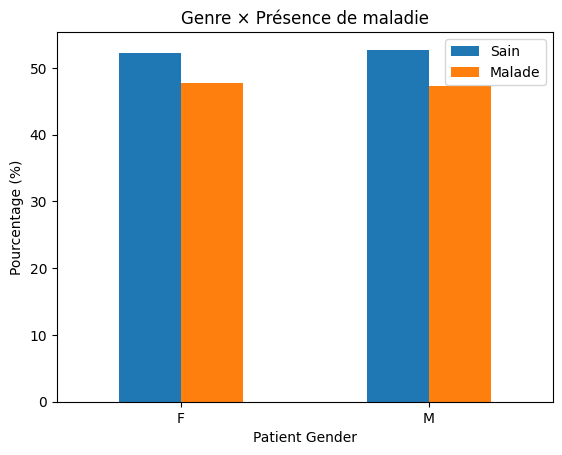

In [36]:
table_genre_maladie.plot(kind="bar")

plt.ylabel("Pourcentage (%)")
plt.title("Genre × Présence de maladie")
plt.xticks(rotation=0)
plt.legend(["Sain", "Malade"])
plt.show()

In [37]:
print(f"Différence hommes - femmes : {(table_genre_maladie.loc["M", True] - table_genre_maladie.loc["F", True]):.2f} points de pourcentage")

Différence hommes - femmes : -0.45 points de pourcentage


In [38]:
from scipy.stats import chi2_contingency

contingence = pd.crosstab(df["Patient Gender"], df["Has_Disease"])
chi2, p, dof, expected = chi2_contingency(contingence)

print("p-value :", p)

p-value : 0.7633824344663006


Le test du χ² donne une p-value de 0.0196, inférieure au seuil de 5 %, ce qui indique que la relation entre le genre et la présence de maladie est statistiquement significative. Toutefois, l’écart observé entre les proportions reste modéré, ce qui suggère que l’effet est présent mais de faible ampleur.

In [39]:
rr = table_genre_maladie.loc["M", True] / table_genre_maladie.loc["F", True]
rr

np.float64(0.9906276458103747)

Le risk ratio est égal à 1.06, ce qui signifie que les hommes ont une probabilité environ 6 % plus élevée de présenter une pathologie que les femmes. Bien que statistiquement significative, cette différence reste modérée.

In [40]:
#Genre × Pathologies

# On crée tables_genre_pathologies qui contient, pour chaque pathologie, le tableau de contingence normalisé par ligne
#donant les probabilités de chaque pathologie sachant le genre
# diffs qui contient, pour chaque pathologie, toutes les differences de proportion entre hommes et femmes
# p_values qui contient les p_values des test d'indépendance entre genre et chaque pathologie
# et rrs qui contient le risque ration pour chaque pathologie, ie l'écart de prévalence entre les genres
tables_genre_pathologies = {}
diffs = {}
p_values = {}
rrs = {}

for m in maladies:
    tables_genre_pathologies[m] = pd.crosstab(
        df_one_hot["Patient Gender"],
        df_one_hot[m],
        normalize="index"
    ) * 100

    diffs[m] = tables_genre_pathologies[m].loc["M", 1] - tables_genre_pathologies[m].loc["F", 1]

    contingence = pd.crosstab(df["Patient Gender"], df_one_hot[m])
    _, p, _, _ = chi2_contingency(contingence)
    p_values[m] = p

    rrs[m] = tables_genre_pathologies[m].loc["M", True] / tables_genre_pathologies[m].loc["F", True]


diffs = pd.Series(diffs).sort_values(ascending=False)
rrs = pd.Series(rrs).reindex(diffs.index)
p_values = pd.Series(p_values).reindex(diffs.index)

In [41]:
#On affiche tables_genre_pathologies

def plot_gender_disease(maladie):
    table = tables_genre_pathologies[maladie]  # index: M/F ; colonnes: 0/1


    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Hommes
    axes[0].pie(
        [table.loc["M", 1], table.loc["M", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[0].set_title(f"Hommes (M) — {maladie}")

    # Femmes
    axes[1].pie(
        [table.loc["F", 1], table.loc["F", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[1].set_title(f"Femmes (F) — {maladie}")

    plt.suptitle("Genre × Pathologie (proportions par genre)")
    plt.tight_layout()
    plt.show()

widgets.interact(plot_gender_disease, maladie=maladies)

interactive(children=(Dropdown(description='maladie', options=('Atelectasis', 'Cardiomegaly', 'Consolidation',…

<function __main__.plot_gender_disease(maladie)>

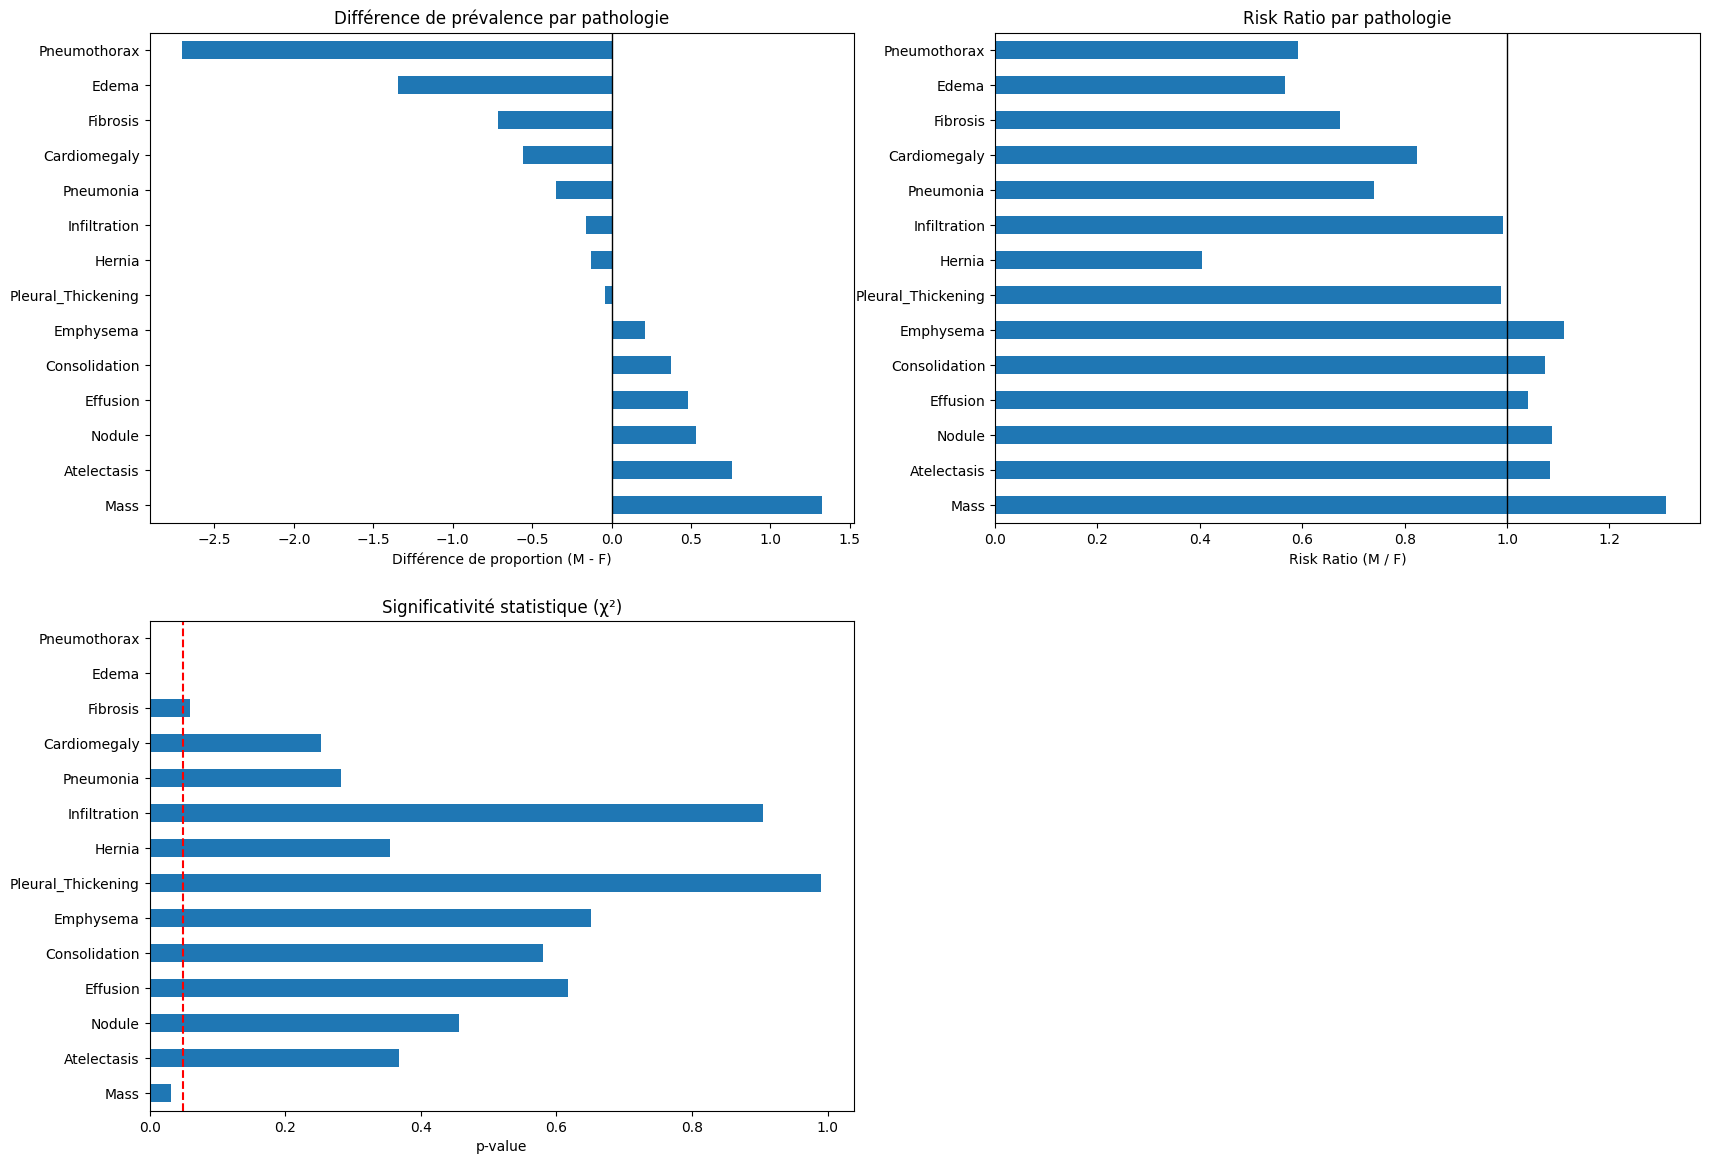

In [42]:
# On affiche les trois autres tableau qui vont nous donner plus d'info sur la posibilité qu¡il y ai un biais 

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes[1][1].remove()

diffs.plot(kind="barh", ax= axes[0][0])
axes[0][0].axvline(0, color="black", linewidth=1)
axes[0][0].set_xlabel("Différence de proportion (M - F)")
axes[0][0].set_title("Différence de prévalence par pathologie")

rrs.plot(kind="barh", ax= axes[0][1])
axes[0][1].axvline(1, color="black", linewidth=1)
axes[0][1].set_xlabel("Risk Ratio (M / F)")
axes[0][1].set_title("Risk Ratio par pathologie")

p_values.plot(kind="barh", ax = axes[1][0])
axes[1][0].axvline(0.05, color="red", linestyle="--")
axes[1][0].set_xlabel("p-value")
axes[1][0].set_title("Significativité statistique (χ²)")

plt.show()

On observe des écarts de proportion notables entre hommes et femmes pour certaines pathologies (ex. atélectasie, masse, infiltration), avec des risk ratios parfois éloignés de 1, suggérant une distribution différenciée selon le sexe.

Cependant, le graphique de significativité (χ²) montre que seules quelques pathologies franchissent le seuil statistique (ligne rouge), indiquant que toutes les différences observées ne sont pas statistiquement significatives.

On refait quasiment la même analyse mais cette fois avec groupe d'âge au lieu de avec genre

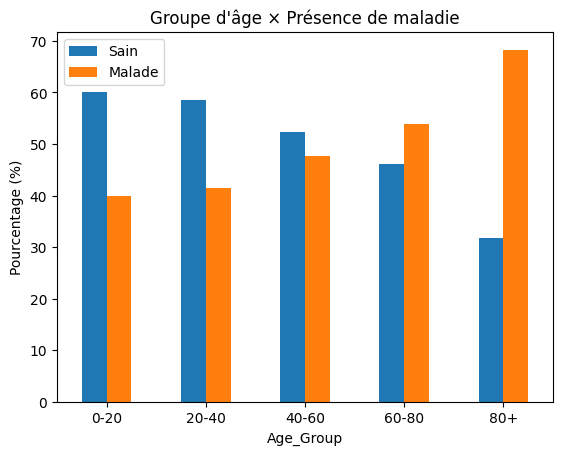

40.0


In [43]:
#Age_group × Maladie
table_age_maladie = pd.crosstab(
    df["Age_Group"],
    df["Has_Disease"],
    normalize="index"
) * 100

table_age_maladie.plot(kind="bar")
plt.ylabel("Pourcentage (%)")
plt.title("Groupe d'âge × Présence de maladie")
plt.xticks(rotation=0)
plt.legend(["Sain", "Malade"])
plt.show()

print(table_age_maladie[True]["0-20"])

In [ ]:
# On prend comme groupe de référence le groupe d'âge 40-60 car c'est le groupe avec le plus de valeures et le plus stable statistiquement

print(table_age_maladie[True] - table_age_maladie[True]["40-60"])

contingence = pd.crosstab(df["Age_Group"],df["Has_Disease"])
chi2, p, dof, expected = chi2_contingency(contingence)

print("p-value :", p)

rr = table_age_maladie / table_age_maladie[True]["40-60"]
print(rr)

Age_Group
0-20     -7.576767
20-40    -6.101357
40-60     0.000000
60-80     6.269387
80+      20.715916
Name: True, dtype: float64
p-value : 7.813846093633881e-11
Has_Disease     False     True 
Age_Group                      
0-20         1.261120  0.840747
20-40        1.230109  0.871758
40-60        1.101866  1.000000
60-80        0.970092  1.131774
80+          0.666445  1.435421


analsye

In [45]:
#Age_Group × Pathologies

tables_age_pathologies = {}
diffs = {}
p_values = {}
rrs = {}

for m in maladies:
    tables_age_pathologies[m] = pd.crosstab(
        df_one_hot["Age_Group"],
        df_one_hot[m],
        normalize="index"
    ) * 100

    diffs[m] = tables_age_pathologies[m][1] - tables_age_pathologies[m][1].loc["40-60"]

    contingence = pd.crosstab(df_one_hot["Age_Group"], df_one_hot[m])
    _, p, _, _ = chi2_contingency(contingence)
    p_values[m] = p

    rrs[m] = tables_age_pathologies[m][1] / tables_age_pathologies[m][1].loc["40-60"]


In [ ]:
#On affiche tables_age_pathologies

def plot_age_disease(maladie):
    table = tables_age_pathologies[maladie]

    fig, axes = plt.subplots(3, 2, figsize=(12, 6))
    axes[2][1].remove()

    # 0-20
    axes[0][0].pie(
        [table.loc["0-20", 1], table.loc["0-20", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[0][0].set_title(f" 0-20 — {maladie}")

    # 20-40
    axes[0][1].pie(
        [table.loc["20-40", 1], table.loc["20-40", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[0][1].set_title(f" 20-40 — {maladie}")

    # 40-60
    axes[1][0].pie(
        [table.loc["40-60", 1], table.loc["40-60", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[1][0].set_title(f" 40-60 — {maladie}")

    # 60-80
    axes[1][1].pie(
        [table.loc["60-80", 1], table.loc["60-80", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[1][1].set_title(f" 60-80 — {maladie}")
    
    # 80+
    axes[2][0].pie(
        [table.loc["80+", 1], table.loc["80+", 0]],
        labels=[f"{maladie} (présent)", "Absent"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[2][0].set_title(f" 80+ — {maladie}")

    plt.suptitle("Groupe d'âge × Pathologie (proportions par âge)")
    plt.tight_layout()
    plt.show()

widgets.interact(plot_age_disease, maladie=maladies)

interactive(children=(Dropdown(description='maladie', options=('Atelectasis', 'Cardiomegaly', 'Consolidation',…

<function __main__.plot_age_disease(maladie)>

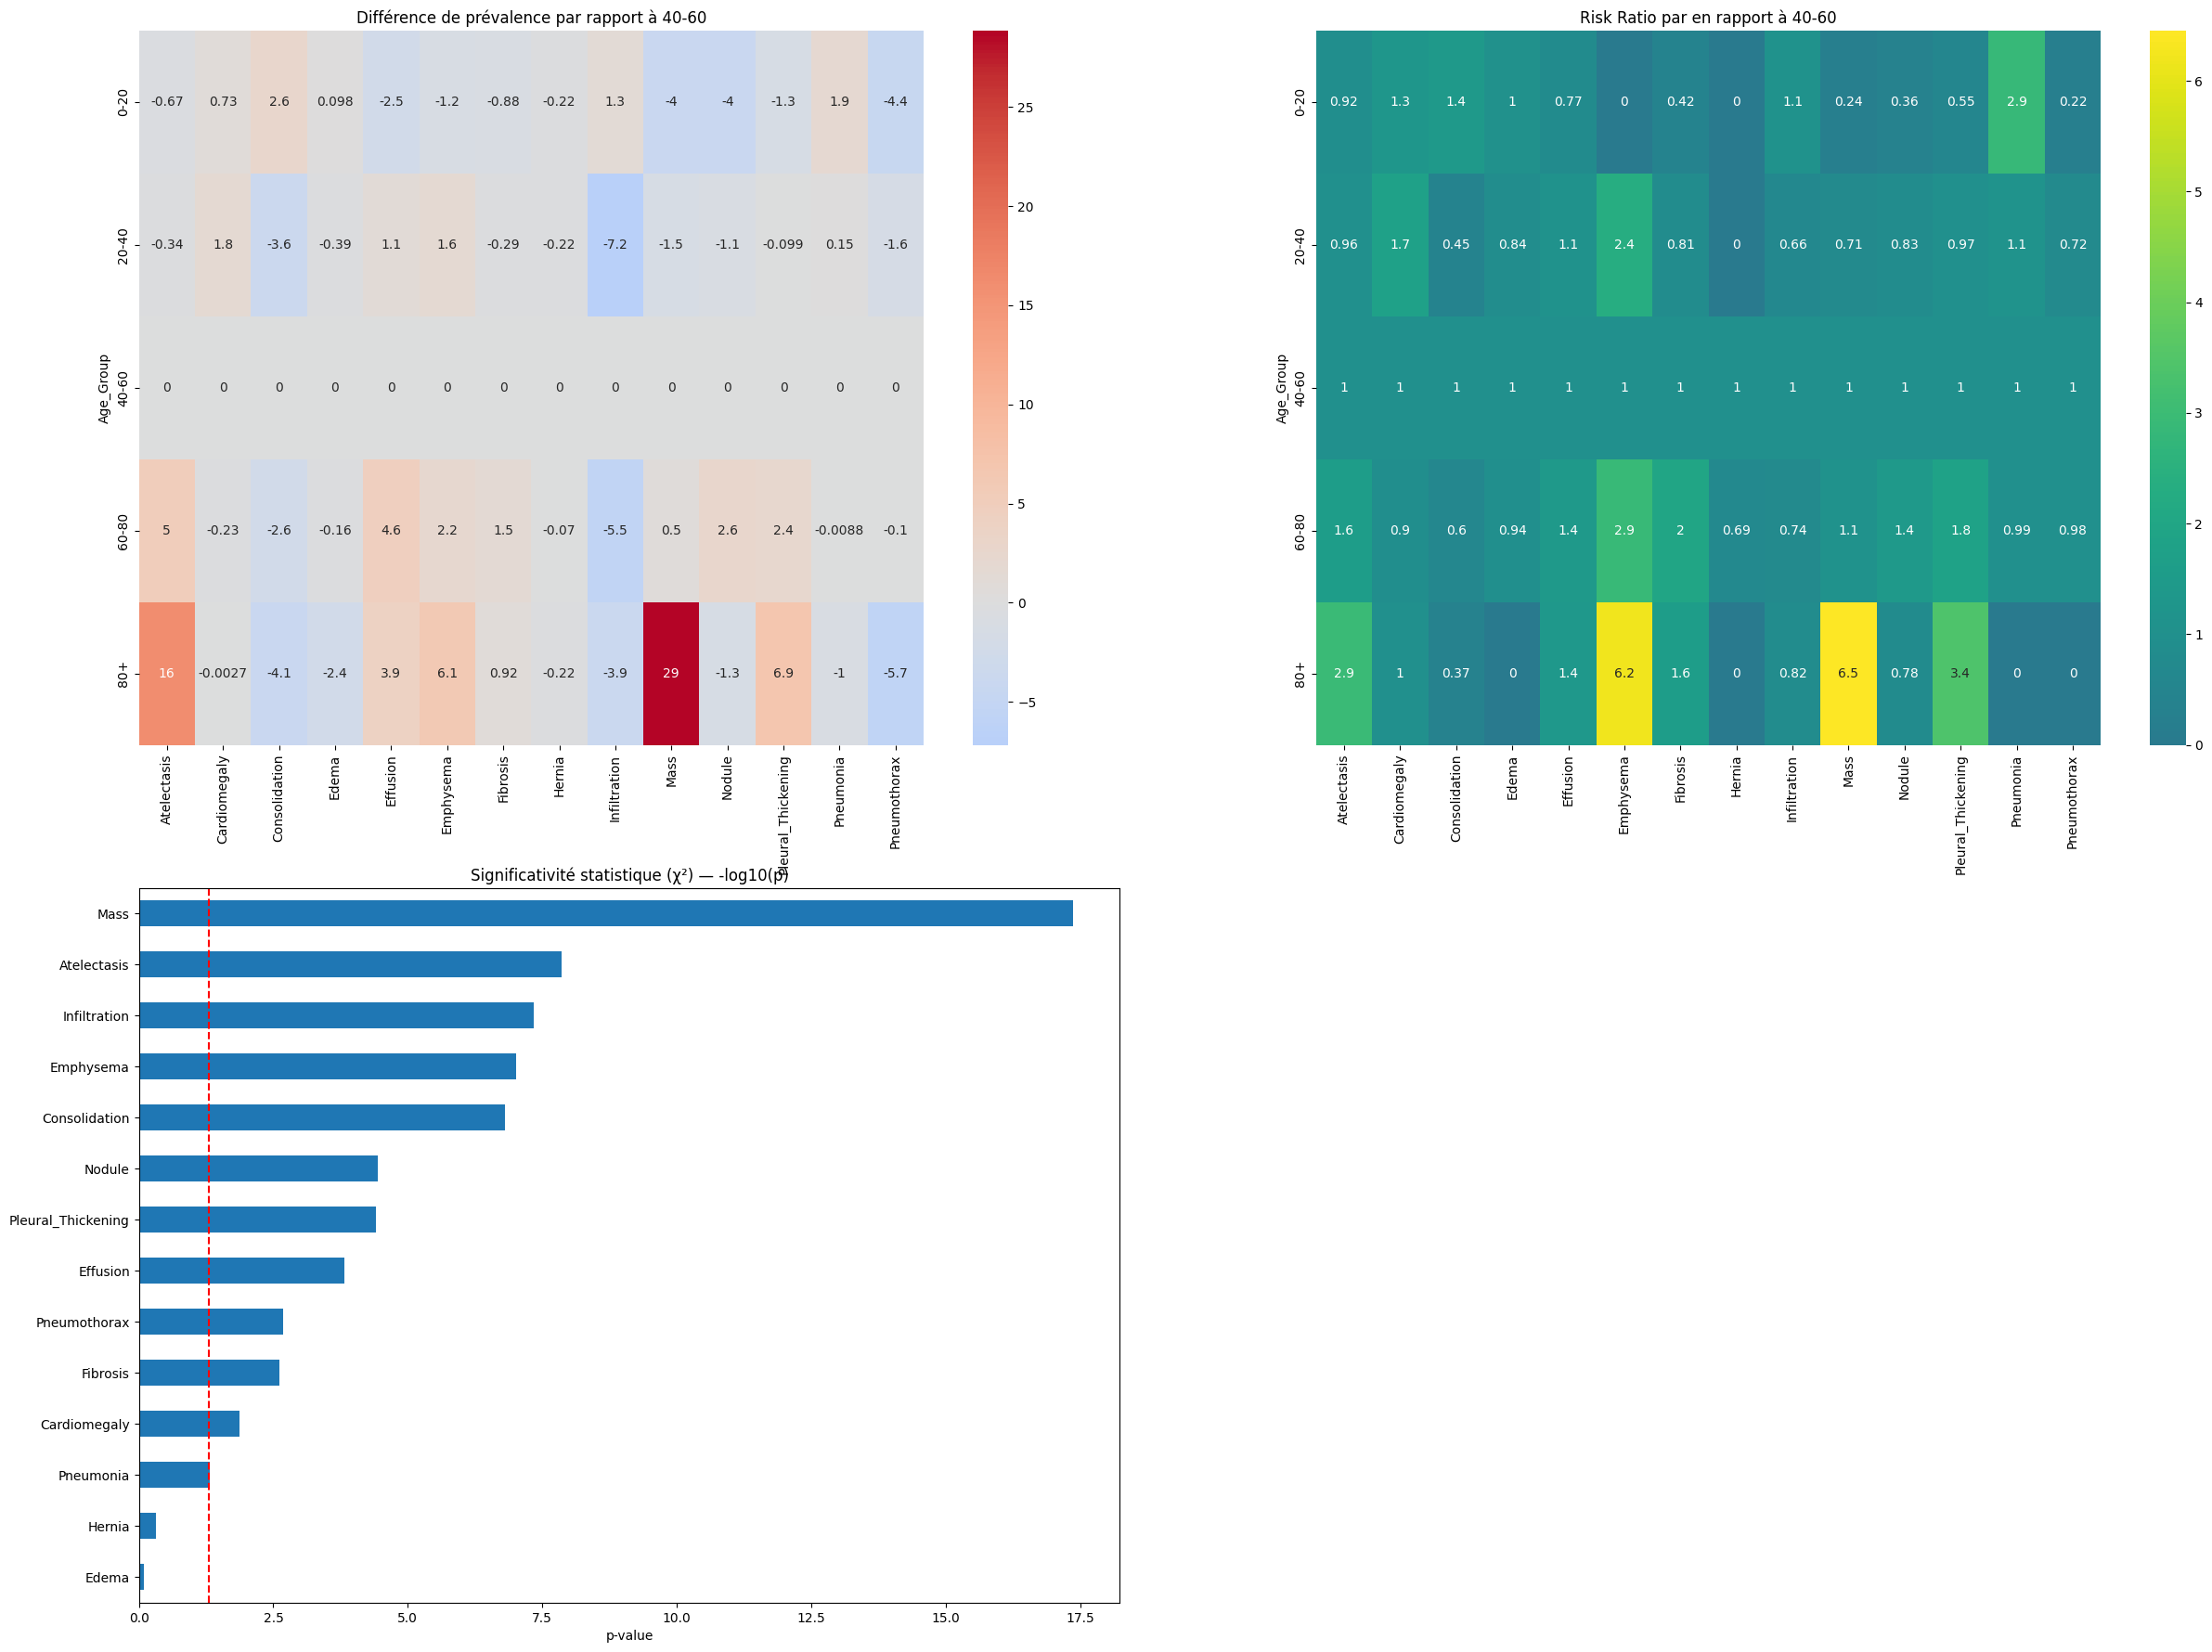

In [47]:
# On affiche les trois autres tableau qui vont nous donner plus d'info sur la posibilité qu¡il y ai un biais, il y a trop de 
# valeures donc on utrilise des heatMaps

fig, axes = plt.subplots(2, 2, figsize=(30, 22))
axes[1][1].remove()

sns.heatmap(pd.DataFrame(diffs),
            annot=True,
            cmap="coolwarm",
            center=0,
            ax = axes[0][0])
axes[0][0].set_title("Différence de prévalence par rapport à 40-60")

sns.heatmap(pd.DataFrame(rrs),
            annot=True,
            cmap="viridis",
            center=1,
            ax = axes[0][1])
axes[0][1].set_title("Risk Ratio par en rapport à 40-60")

axes[1][0] = (-np.log10(pd.Series(p_values).astype(float))).sort_values().plot(kind="barh")
axes[1][0].axvline(-np.log10(0.05), color="red", linestyle="--")
axes[1][0].set_xlabel("p-value")
axes[1][0].set_title("Significativité statistique (χ²) — -log10(p)")

plt.show()

On observe des écarts de prévalence importants selon les groupes d’âge par rapport au groupe 40–60 ans, notamment pour les 80+ où certaines pathologies présentent des risk ratios supérieurs à 1  dont certains très élevées.

Le test du χ² confirme que plusieurs associations âge–pathologie sont statistiquement significatives car plus grandes que le seuil, il y donc une forte dépendance entre l’âge et la présence de certaines maladies.

#  Méthode de mitigation des biais par pré-processing

# Reweighing

In [48]:
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
 
#dataset 
dataset_orig = StandardDataset(
    df=df_one_hot[["Has_Disease", "Patient Gender"]].copy(),
    label_name="Has_Disease",
    favorable_classes=[1],
    protected_attribute_names=["Patient Gender"],
    privileged_classes=[["M"]]   # ← string ici
)

#groupes
privileged_groups = [{"Patient Gender": "M"}]
unprivileged_groups = [{"Patient Gender": "F"}]

#reweighing
rw = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

dataset_rw = rw.fit_transform(dataset_orig)
weights_rw = dataset_rw.instance_weights

/Users/eduardo/Desktop/Cours/L3/Fairness/Mi-Projet/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/Users/eduardo/Desktop/Cours/L3/Fairness/Mi-Projet/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch

In [49]:
y = dataset_orig.labels[:,0]
g = dataset_orig.protected_attributes[:,0]

p_m_before = y[g==1].mean()
p_f_before = y[g==0].mean()

spd_before = p_f_before - p_m_before
di_before  = p_f_before / p_m_before

p_m_after = np.average(y[g==1], weights=weights_rw[g==1])
p_f_after = np.average(y[g==0], weights=weights_rw[g==0])

spd_after = p_f_after - p_m_after
di_after  = p_f_after / p_m_after

print("AVANT")
print(f"SPD : {spd_before:.4f}")
print(f"DI  : {di_before:.4f}")

print("\nAPRES Reweighing")
print(f"SPD : {spd_after:.4f}")
print(f"DI  : {di_after:.4f}")


AVANT
SPD : 0.0045
DI  : 1.0095

APRES Reweighing
SPD : 0.0045
DI  : 1.0095


# Conclusion

Nous avons analysé un sous-ensemble de ~15 000 patients du dataset NIH Chest X-Ray, en agrégeant au niveau patient pour éviter les biais liés aux suivis multiples. Cependant pour l'entrainement du modèle on négligera ceci car une même personne peut avoir plusieures radiographies certaines avec des maladies et certaines sans. 

On a identifie notamment deux source de biais:

    Genre : Le dataset est déséquilibré. Cependant, le biais en termes de taux de pathologie est faible donc ça n'aura pas beaucoup d'importance.
    Âge : Le biais est nettement plus marqué. Les patients >80 ans présentent un taux de pathologie significativement supérieur au reste.

Un Reweigthing à été effectué sur le genre, comme il était supposée, il n'a rien changé car le biais était trop petit. Par contre le reweigthing sur les ages présentait des erreures dans le code donc je l'ai omis, c'est la limite principale de ce projet 
